# Backtesting Trimestral 2025 — RNN-LSTM (Volume Bars)

Análisis comparativo de **5 estrategias** de inversión sobre el universo de 23 activos durante 2025, con rebalanceo trimestral.

| Estrategia | Descripción |
|---|---|
| `model_top4_equal` | Top-4 por retorno predicho; pesos iguales |
| `model_top4_riskadjusted` | Top-4 por retorno predicho / volatilidad trailing |
| `model_top4_threshold` | Como Equal, pero solo activos con predicción > umbral; resto en cash |
| `model_top4_propweights` | Top-4 por retorno predicho; pesos proporcionales a la predicción (solo positivos) |
| `model_longshort` | Long top-4 / short bottom-4 por retorno predicho; pesos iguales (±25 %). Estrategia market-neutral |
| `bench_momentum` | Top-4 por retorno realizado en los últimos 90 días |
| `bench_momentum_input` | Top-4 por retorno realizado en los últimos N días (= ventana de entrada del modelo) |
| `bench_equalweight` | Buy & Hold con peso igual en los 23 activos |

**Modelo**: RNN-LSTM (input = 10 días, output = media de 90 días)  
**Tipo de bars**: Volume bars (secuencias pre-generadas por `03_build_preprocessed_sequences.py`)  
**Arquitectura ganadora**: 2 capas LSTM · 128 unidades · sin dropout · lr = 1e-4 · batch = 128  
**Entrenamiento**: datos hasta 31-dic-2024 | **Test out-of-sample**: 2025

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

# Añadimos project root, model/cnn y scripts al path
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
SCRIPTS_DIR = NOTEBOOK_DIR.parent / "scripts"

for _p in [str(PROJECT_ROOT), str(PROJECT_ROOT / "model" / "cnn"), str(SCRIPTS_DIR)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import backtest_quarterly_momentum as bt

bt.setup(model_type="lstm", input_window=10, output_window=90, bar_type="volume")

Modelo no encontrado. Entrenando con train_lstm_in10_out90_to2024.run() ...
Cargando datos desde NPZ — bar_type=volume ...
X_train: (2648, 10, 23)  X_val: (294, 10, 23)  X_test: (327, 10, 23)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 128)        │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,375 (829.59 KB)

 Trainable params: 212,375 (829.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0032 - val_loss: 0.0027
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028 - val_loss: 0.0026
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 10/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 11/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 12/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

## 1. Universo de activos

El universo está compuesto por **23 acciones del mercado estadounidense** (NYSE/NASDAQ).
Mostramos las estadísticas de retorno logarítmico diario durante el periodo de test (2025).

In [2]:
returns_2025 = bt.returns_full.loc["2025"]

print(f"Periodo out-of-sample : {returns_2025.index[0].date()} → {returns_2025.index[-1].date()}")
print(f"Días de trading       : {len(returns_2025)}")
print(f"\nActivos ({bt.n_assets}):")
print(bt.assets)

# Estadísticas de retorno diario en porcentaje
stats = (returns_2025.describe().T[["mean", "std", "min", "max"]] * 100).round(4)
stats.columns = ["Media diaria (%)", "Vol. diaria (%)", "Mínimo (%)", "Máximo (%)"]
display(stats.sort_values("Media diaria (%)", ascending=False))

Periodo out-of-sample : 2025-01-02 → 2025-12-31
Días de trading       : 250

Activos (23):
['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


,Media diaria (%),Vol. diaria (%),Mínimo (%),Máximo (%)
Ticker,,,,
GE,0.2477,1.9178,-11.7617,10.0466
CAT,0.1888,2.0022,-9.0315,11.0061
JNJ,0.1554,1.2355,-7.8953,6.0090
IBM,0.1295,1.8824,-7.9301,12.1900
GD,0.1062,1.3355,-7.5513,6.5128
AEP,0.1030,1.2192,-4.3361,5.9034
MMM,0.0936,1.8608,-9.6305,8.4124
CNP,0.0852,1.0415,-3.4862,2.8763
BA,0.0817,2.3586,-11.0608,14.3010


## 2. Predicciones del LSTM (Volume) en cada rebalanceo

En cada fecha de rebalanceo el modelo recibe los **últimos 10 días de retornos** de los 23 activos
y predice la **media del log-return diario** en los próximos 90 días.

> **Interpretación del eje X**: la predicción se multiplica × 252 para aproximar un retorno
> anualizado (no es el retorno acumulado de 90 días). Los activos en azul son los 4 seleccionados.

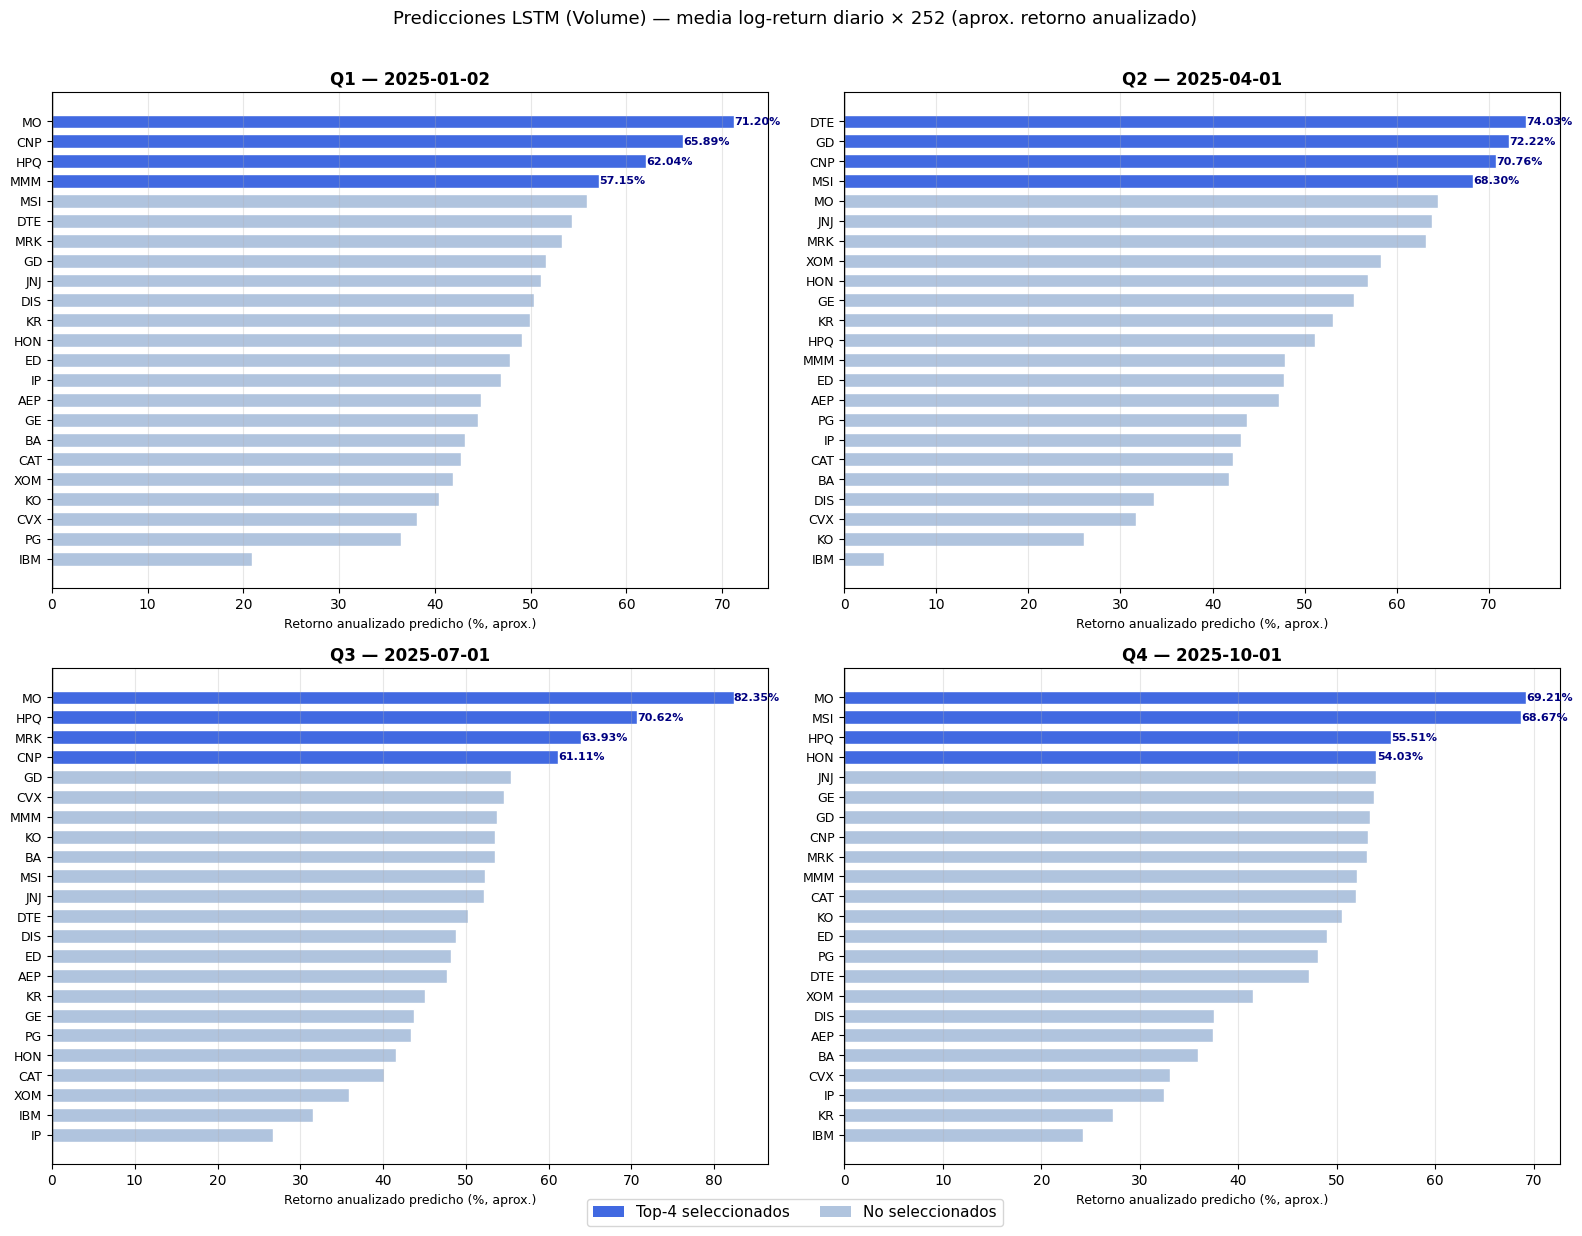

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for q_idx, (rb_date, ax) in enumerate(zip(bt.rebalance_dates, axes)):
    pred = bt.predict_at(rb_date)
    top4_idx = set(int(i) for i in np.argsort(pred)[::-1][:bt.N_TOP])
    order = list(np.argsort(pred))

    sorted_assets = [bt.assets[j] for j in order]
    pred_annual   = [float(pred[j]) * 252 * 100 for j in order]
    colors        = ["royalblue" if j in top4_idx else "lightsteelblue" for j in order]

    bars = ax.barh(sorted_assets, pred_annual, color=colors, edgecolor="white", height=0.7)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"Q{q_idx + 1} — {rb_date.strftime('%Y-%m-%d')}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Retorno anualizado predicho (%, aprox.)", fontsize=9)
    ax.grid(True, alpha=0.3, axis="x")
    ax.tick_params(axis="y", labelsize=9)

    for j_pos, (bar, val, j) in enumerate(zip(bars, pred_annual, order)):
        if j in top4_idx:
            ax.text(
                val + 0.03, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%", va="center", fontsize=8, color="navy", fontweight="bold",
            )

legend_elems = [
    mpatches.Patch(facecolor="royalblue",      label="Top-4 seleccionados"),
    mpatches.Patch(facecolor="lightsteelblue", label="No seleccionados"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    "Predicciones LSTM (Volume) — media log-return diario × 252 (aprox. retorno anualizado)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## 3. Ejecución del backtest

Ejecutamos el backtest trimestral para las 5 estrategias y mostramos qué activos selecciona cada una en cada periodo.

In [4]:
ret_df, holdings = bt.run_backtest()

LABELS = {
    "model_top4_equal":        "LSTM (Vol) Equal",
    "model_top4_riskadjusted": "LSTM (Vol) Risk-Adj.",
    "model_top4_threshold":    "LSTM (Vol) Umbral",
    "model_top4_propweights":  "LSTM (Vol) Prop. Pesos",
    "model_longshort":         "LSTM (Vol) Long-Short",
    "bench_momentum":          "Momentum 90d",
    "bench_momentum_input":    f"Momentum {bt.INPUT_WINDOW}d",
    "bench_equalweight":       "Equal Weight",
}

# Tabla de selección de activos por trimestre
quarter_names = [f"Q{i+1} ({d.strftime('%b %Y')})" for i, d in enumerate(bt.rebalance_dates)]
rows = {}
for name, label in LABELS.items():
    row = []
    for q in range(len(bt.rebalance_dates)):
        if q < len(holdings[name]):
            h = holdings[name][q]
            if name == "bench_equalweight":
                row.append("todos (1/23)")
            elif name == "model_longshort":
                pred_q  = bt.predict_at(bt.rebalance_dates[q])
                order_q = np.argsort(pred_q)[::-1]
                long_a  = sorted([bt.assets[i] for i in order_q[:bt.N_TOP]])
                short_a = sorted([bt.assets[i] for i in order_q[-bt.N_TOP:]])
                row.append("L: " + ", ".join(long_a) + " | S: " + ", ".join(short_a))
            elif not h:
                row.append("cash")
            else:
                row.append(", ".join(sorted(h)))
        else:
            row.append("—")
    rows[label] = row

sel_df = pd.DataFrame(rows, index=quarter_names).T
display(sel_df)

Q1 (2025-01-02): pred top-4 = ['MO', 'CNP', 'HPQ', 'MMM']
Q2 (2025-04-01): pred top-4 = ['DTE', 'GD', 'CNP', 'MSI']
Q3 (2025-07-01): pred top-4 = ['MO', 'HPQ', 'MRK', 'CNP']
Q4 (2025-10-01): pred top-4 = ['MO', 'MSI', 'HPQ', 'HON']


,Q1 (Jan 2025),Q2 (Apr 2025),Q3 (Jul 2025),Q4 (Oct 2025)
LSTM (Vol) Equal,"CNP, HPQ, MMM, MO","CNP, DTE, GD, MSI","CNP, HPQ, MO, MRK","HON, HPQ, MO, MSI"
LSTM (Vol) Risk-Adj.,"CNP, DTE, JNJ, MO","CNP, DTE, GD, JNJ","CNP, DTE, KO, MO","CNP, KO, MO, MSI"
LSTM (Vol) Umbral,"CNP, HPQ, MMM, MO","CNP, DTE, GD, MSI","CNP, HPQ, MO, MRK","HON, HPQ, MO, MSI"
LSTM (Vol) Prop. Pesos,"CNP, HPQ, MMM, MO","CNP, DTE, GD, MSI","CNP, HPQ, MO, MRK","HON, HPQ, MO, MSI"
LSTM (Vol) Long-Short,"L: CNP, HPQ, MMM, MO | S: CVX, IBM, KO, PG","L: CNP, DTE, GD, MSI | S: CVX, DIS, IBM, KO","L: CNP, HPQ, MO, MRK | S: CAT, IBM, IP, XOM","L: HON, HPQ, MO, MSI | S: CVX, IBM, IP, KR"
Momentum 90d,"CNP, DIS, HON, KR","BA, CNP, IBM, KO","BA, GD, GE, MO","CAT, GD, GE, JNJ"
Momentum 10d,"AEP, BA, GE, JNJ","BA, CVX, MSI, XOM","CAT, GE, KR, MMM","AEP, CAT, DTE, IBM"
Equal Weight,todos (1/23),todos (1/23),todos (1/23),todos (1/23)


## 4. Retorno acumulado

Evolución del valor de la cartera (base 100) a lo largo de 2025.
Las líneas verticales punteadas marcan las fechas de rebalanceo trimestral.

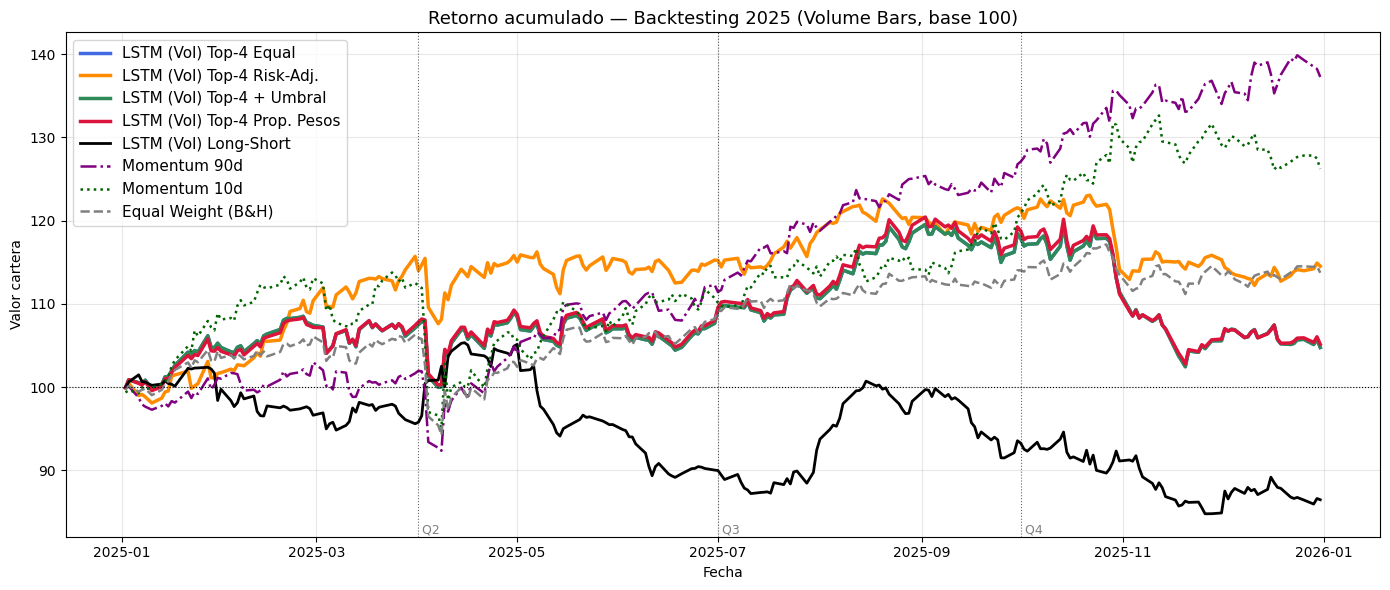

Retorno final (base 100):
  LSTM (Vol) Top-4 Equal             : 104.76  (+4.76 %)
  LSTM (Vol) Top-4 Risk-Adj.         : 114.52  (+14.52 %)
  LSTM (Vol) Top-4 + Umbral          : 104.76  (+4.76 %)
  LSTM (Vol) Top-4 Prop. Pesos       : 105.14  (+5.14 %)
  LSTM (Vol) Long-Short              : 86.47  (-13.53 %)
  Momentum 90d                       : 137.25  (+37.25 %)
  Momentum 10d                       : 126.20  (+26.20 %)
  Equal Weight (B&H)                 : 113.73  (+13.73 %)


In [5]:
cum_value = ret_df.cumsum().apply(np.exp) * 100

STYLE = {
    "model_top4_equal":        dict(color="royalblue",  lw=2.5, ls="-",  label="LSTM (Vol) Top-4 Equal"),
    "model_top4_riskadjusted": dict(color="darkorange", lw=2.5, ls="-",  label="LSTM (Vol) Top-4 Risk-Adj."),
    "model_top4_threshold":    dict(color="seagreen",   lw=2.5, ls="-",  label="LSTM (Vol) Top-4 + Umbral"),
    "model_top4_propweights":  dict(color="crimson",    lw=2.5, ls="-",  label="LSTM (Vol) Top-4 Prop. Pesos"),
    "model_longshort":         dict(color="black",      lw=2.0, ls="-",  label="LSTM (Vol) Long-Short"),
    "bench_momentum":          dict(color="purple",     lw=1.8, ls="-.", label="Momentum 90d"),
    "bench_momentum_input":    dict(color="darkgreen",  lw=1.8, ls=":",  label=f"Momentum {bt.INPUT_WINDOW}d"),
    "bench_equalweight":       dict(color="gray",       lw=1.8, ls="--", label="Equal Weight (B&H)"),
}

fig, ax = plt.subplots(figsize=(14, 6))
for name, style in STYLE.items():
    ax.plot(cum_value.index, cum_value[name], **style)

for i, rb in enumerate(bt.rebalance_dates[1:], start=2):
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.text(rb, ax.get_ylim()[0], f" Q{i}", fontsize=9, color="gray", va="bottom")

ax.axhline(100, color="black", lw=0.8, ls=":")
ax.set_title("Retorno acumulado — Backtesting 2025 (Volume Bars, base 100)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Retorno final (base 100):")
for name, style in STYLE.items():
    final = float(cum_value[name].iloc[-1])
    print(f"  {style['label']:35s}: {final:.2f}  ({final - 100:+.2f} %)")

## 5. Métricas de rendimiento

| Métrica | Descripción |
|---|---|
| **Retorno total (%)** | Ganancia acumulada en 2025 |
| **Sharpe ratio** | Retorno ajustado por riesgo (rf = 4 % anual) |
| **Max Drawdown (%)** | Caída máxima desde un máximo histórico |
| **Turnover medio** | Fracción de activos cambiados entre trimestres (0 = sin cambios, 1 = cartera completamente nueva) |

,Retorno (%),Sharpe,Max DD (%),Turnover
LSTM (Vol) Equal,4.76,0.044,-14.29,1.333
LSTM (Vol) Risk-Adj.,14.52,0.688,-8.81,0.667
LSTM (Vol) Umbral,4.76,0.044,-14.29,1.333
LSTM (Vol) Prop. Pesos,5.14,0.069,-14.66,1.333
LSTM (Vol) Long-Short,-13.53,-1.170,-19.51,2.333
Momentum 90d,37.25,1.726,-10.33,1.333
Momentum 10d,26.20,0.984,-16.39,1.667
Equal Weight,13.73,0.653,-11.33,0.000


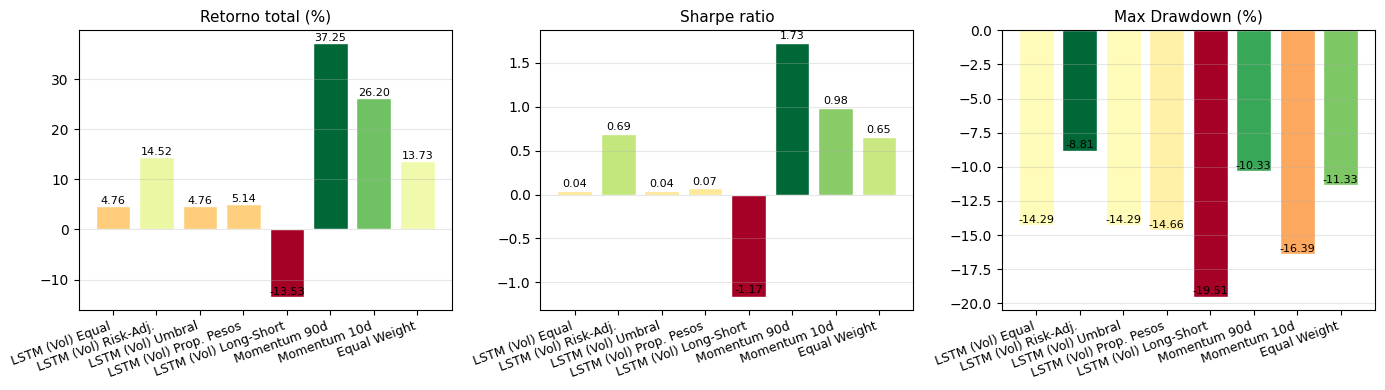

In [6]:
metrics_rows = [bt.compute_metrics(n, ret_df, holdings) for n in bt.STRATEGIES]
metrics = pd.DataFrame(metrics_rows).set_index("strategy")
metrics.index = [LABELS.get(n, n) for n in metrics.index]
metrics.columns = ["Retorno (%)", "Sharpe", "Max DD (%)", "Turnover"]

display(
    metrics.style
    .format({"Retorno (%)": "{:.2f}", "Sharpe": "{:.3f}", "Max DD (%)": "{:.2f}", "Turnover": "{:.3f}"})
    .background_gradient(subset=["Retorno (%)"], cmap="RdYlGn")
    .background_gradient(subset=["Sharpe"],      cmap="RdYlGn")
    .background_gradient(subset=["Max DD (%)"],  cmap="RdYlGn")
    .set_caption("Métricas de backtesting 2025 — LSTM Volume Bars")
)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols   = ["Retorno (%)", "Sharpe", "Max DD (%)"]
cmaps  = ["RdYlGn", "RdYlGn", "RdYlGn"]
titles = ["Retorno total (%)", "Sharpe ratio", "Max Drawdown (%)"]

for ax, col, cmap_name, title in zip(axes, cols, cmaps, titles):
    vals   = metrics[col]
    cmap   = plt.get_cmap(cmap_name)
    norm   = plt.Normalize(vals.min(), vals.max())
    colors = [cmap(norm(v)) for v in vals]
    bars   = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

### Interpretación de los resultados — Estrategia Long-Short

Los malos resultados de la estrategia Long-Short son **informativos, no un fallo del modelo**. Permiten extraer conclusiones importantes sobre la naturaleza predictiva del LSTM.

**¿Por qué las estrategias long-only funcionan pero la long-short no?**

Las estrategias long-only se benefician del **beta de mercado**: si el modelo predice retornos positivos para la mayoría de activos y se compran los 4 mejores, parte del retorno procede simplemente de que el mercado sube en conjunto. La estrategia long-short es **market-neutral**: elimina ese efecto y constituye una apuesta pura sobre la capacidad del modelo para *ordenar* activos entre sí (señal cross-sectional).

**Lo que el resultado revela**

El LSTM fue entrenado minimizando el MAE sobre retornos absolutos, no sobre el ranking relativo entre activos. Un modelo que predice "todos los activos tendrán ~0.05% diario" obtiene un MAE bajo, pero su poder de ordenación cross-sectional puede ser nulo. Si los activos del bottom-4 no son sistemáticamente peores que los del top-4, la pata corta destruye valor activamente en lugar de añadirlo.

| Estrategia | Fuente principal de retorno |
|---|---|
| Long-only (Equal, Risk-Adj., Umbral, Prop.) | Beta de mercado + señal del modelo |
| **Long-Short** | **Solo señal cross-sectional del modelo** |

El rendimiento positivo de las estrategias long-only no implica necesariamente que el modelo tenga buen poder predictivo sobre el *ranking* de activos. La long-short desenmascara esa distinción.

> **Posible mejora:** para que una estrategia long-short funcione, el modelo debería entrenarse con una función de pérdida orientada al ranking (p.ej. *pairwise ranking loss* o *ListNet*) en lugar de MAE, de modo que el gradiente de entrenamiento penalice directamente los errores de ordenación entre activos.

## 6. Análisis de drawdown

El drawdown mide la caída porcentual respecto al máximo histórico de la cartera.
Es el indicador de riesgo más visible para un inversor real.

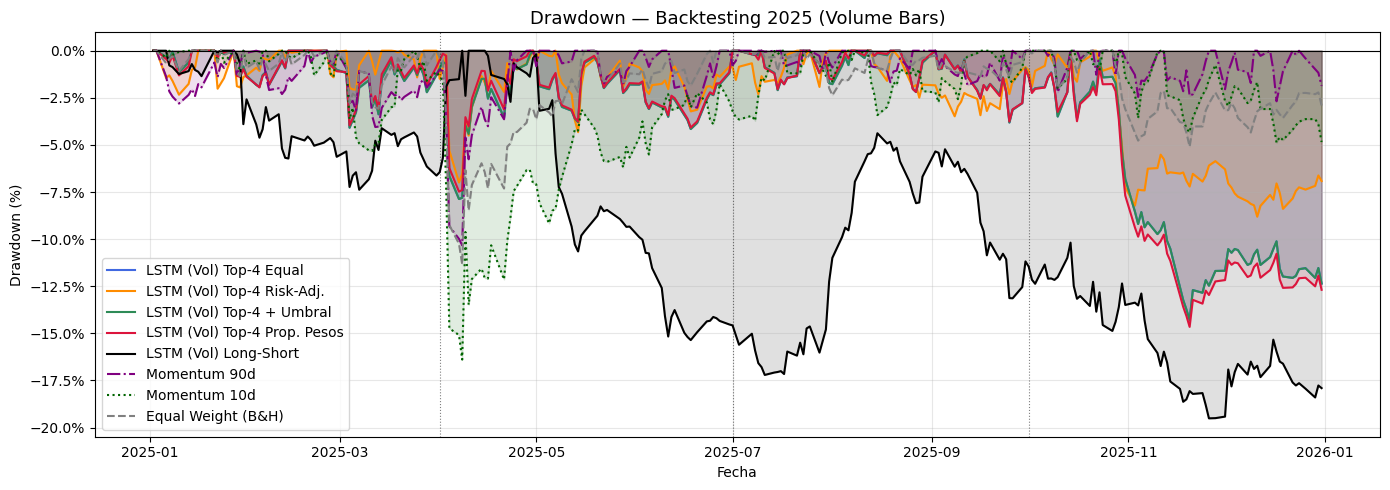

Max Drawdown por estrategia:
  LSTM (Vol) Top-4 Equal             : -14.29 %
  LSTM (Vol) Top-4 Risk-Adj.         : -8.81 %
  LSTM (Vol) Top-4 + Umbral          : -14.29 %
  LSTM (Vol) Top-4 Prop. Pesos       : -14.66 %
  LSTM (Vol) Long-Short              : -19.51 %
  Momentum 90d                       : -10.33 %
  Momentum 10d                       : -16.39 %
  Equal Weight (B&H)                 : -11.33 %


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.12, color=style["color"])
    ax.plot(dd.index, dd, lw=1.5, color=style["color"], ls=style["ls"], label=style["label"])

for rb in bt.rebalance_dates[1:]:
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.5)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Drawdown — Backtesting 2025 (Volume Bars)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
ax.legend(fontsize=10, loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Max Drawdown por estrategia:")
for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    print(f"  {style['label']:35s}: {float(dd.min()):.2f} %")

## 7. Variabilidad de las predicciones entre trimestres

A diferencia del CNN (que convergía a un predictor constante), el LSTM pasó los tests de variabilidad: para cada activo, la desviación estándar de las predicciones a lo largo del tiempo es significativamente mayor que cero.

Esto significa que el LSTM **sí responde al input** que recibe en cada fecha de rebalanceo y que los cambios de selección entre trimestres son informativos.

> **Nota sobre los benchmarks de momentum:**  
> Se incluyen dos variantes para situar el rendimiento del modelo en contexto:
> - **Momentum 90d** (`bench_momentum`): lookback de 90 días, igual al horizonte de inversión. Es el benchmark estándar en la literatura y representa una estrategia real que un inversor podría usar, aunque dispone de más información histórica que el modelo.
> - **Momentum Nd** (`bench_momentum_input`): lookback igual a la ventana de entrada del modelo. Garantiza que ambos parten de exactamente la misma información histórica; es la comparación equitativa para evaluar si el modelo añade valor sobre la tendencia más reciente.

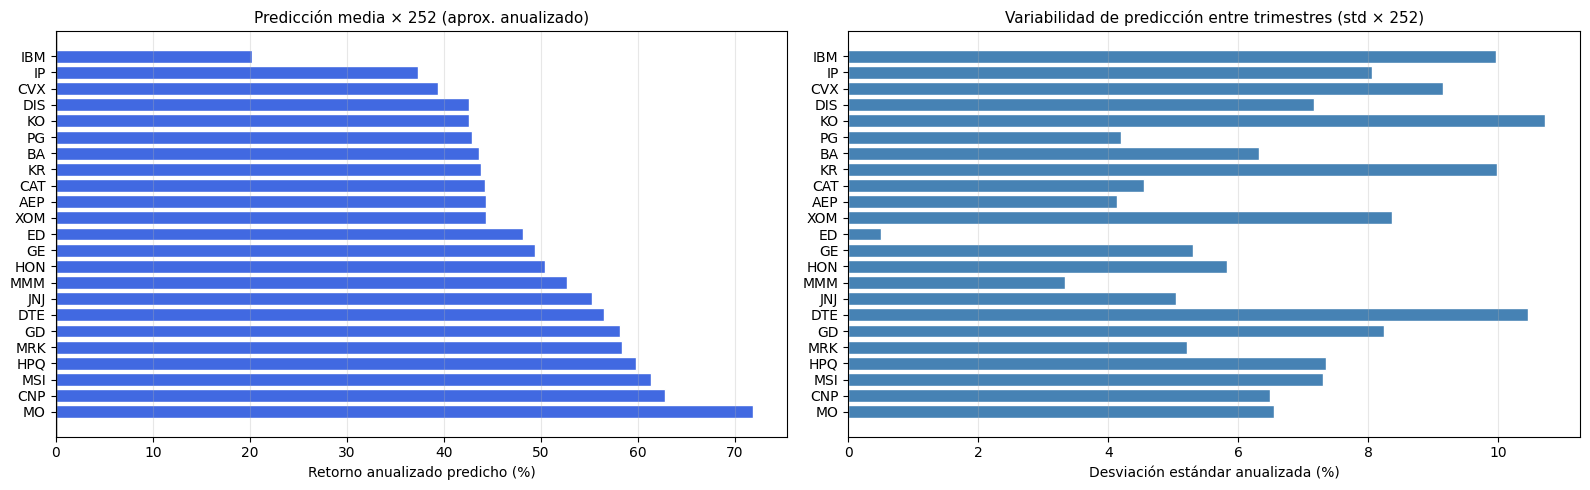

Activos con std de predicción > 0: 23 / 23
Std media entre activos: 0.000266


In [8]:
# Predicciones en cada fecha de rebalanceo
preds_per_quarter = np.array([bt.predict_at(d) for d in bt.rebalance_dates])
# preds_per_quarter: (n_quarters, n_assets)

pred_std = preds_per_quarter.std(axis=0)   # desviación por activo entre trimestres
pred_mean = preds_per_quarter.mean(axis=0)

order = np.argsort(pred_mean)[::-1]
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: predicción media anualizada por activo
ax = axes[0]
vals = pred_mean[order] * 252 * 100
colors = ["royalblue" if v > 0 else "salmon" for v in vals]
ax.barh([bt.assets[i] for i in order], vals, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=1)
ax.set_title("Predicción media × 252 (aprox. anualizado)", fontsize=11)
ax.set_xlabel("Retorno anualizado predicho (%)")
ax.grid(True, alpha=0.3, axis="x")

# Panel derecho: desviación estándar de la predicción entre trimestres
ax = axes[1]
std_vals = pred_std[order] * 252 * 100
ax.barh([bt.assets[i] for i in order], std_vals, color="steelblue", edgecolor="white")
ax.set_title("Variabilidad de predicción entre trimestres (std × 252)", fontsize=11)
ax.set_xlabel("Desviación estándar anualizada (%)")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print(f"Activos con std de predicción > 0: {(pred_std > 1e-6).sum()} / {len(bt.assets)}")
print(f"Std media entre activos: {pred_std.mean():.6f}")

## 8. Rentabilidad neta de comisiones

Se aplica una comisión del **0,23 %** sobre el valor efectivo de cada operación.

**Modelo de costes:**
- En el primer trimestre (compra inicial) se paga comisión sobre el 100 % del capital invertido.
- En cada rebalanceo posterior se paga comisión únicamente por las posiciones que entran y salen:
  - Por cada activo que **sale**: se vende su parte proporcional de la cartera → comisión = 0,23 % × (V / N).
  - Por cada activo que **entra**: se compra al mismo importe → comisión = 0,23 % × (V / N).
- `bench_equalweight` mantiene los mismos 23 activos todos los trimestres → solo paga la comisión inicial.

La clave del análisis: aunque el Momentum supera al LSTM en retorno bruto, su mayor rotación trimestral puede erosionar esa ventaja una vez descontadas las comisiones.

In [9]:
COMMISSION_RATE = 0.0023   # 0,23 % sobre valor efectivo de cada operación

def compute_net_portfolio(strategy_name, ret_df, holdings, rebalance_dates):
    """Devuelve la serie de valor de cartera (base 100) neta de comisiones."""
    log_rets   = ret_df[strategy_name]
    hold_sets  = holdings[strategy_name]
    port_value = 100.0
    values     = []
    prev_set   = set()
    q_idx      = 0

    for date in log_rets.index:
        # ── Comisión al inicio de cada trimestre ──────────────────────────
        if q_idx < len(rebalance_dates) and date == rebalance_dates[q_idx]:
            curr_set = hold_sets[q_idx] if q_idx < len(hold_sets) else set()
            n_sell   = len(prev_set - curr_set)
            n_buy    = len(curr_set - prev_set)
            n_pos    = len(curr_set) or len(prev_set)   # posiciones activas para valorar
            if n_pos > 0:
                # cada posición vale port_value / n_pos
                port_value -= (n_sell + n_buy) * (port_value / n_pos) * COMMISSION_RATE
            prev_set = curr_set
            q_idx   += 1

        # ── Retorno diario ────────────────────────────────────────────────
        port_value *= np.exp(log_rets[date])
        values.append(port_value)

    return pd.Series(values, index=log_rets.index)


# ── Calcular series netas ─────────────────────────────────────────────────────
net_portfolios = {
    name: compute_net_portfolio(name, ret_df, holdings, bt.rebalance_dates)
    for name in bt.STRATEGIES
}
net_df = pd.DataFrame(net_portfolios)

# ── Tabla comparativa bruto vs neto ──────────────────────────────────────────
gross_final = (ret_df.cumsum().apply(np.exp) * 100).iloc[-1]
net_final   = net_df.iloc[-1]

commission_drag = gross_final - net_final   # puntos de cartera perdidos

# Coste total en trimestres: reconstruir comisiones por estrategia
def total_commission_pct(strategy_name):
    hold_sets = holdings[strategy_name]
    prev_set  = set()
    cost_pct  = 0.0
    for q_idx, curr_set in enumerate(hold_sets):
        n_sell = len(prev_set - curr_set)
        n_buy  = len(curr_set - prev_set)
        n_pos  = len(curr_set) or len(prev_set)
        if n_pos > 0:
            cost_pct += (n_sell + n_buy) / n_pos * COMMISSION_RATE * 100
        prev_set = curr_set
    return round(cost_pct, 4)

compare = pd.DataFrame({
    "Retorno bruto (%)":  (gross_final - 100).round(2),
    "Retorno neto (%)":   (net_final   - 100).round(2),
    "Coste comis. (p.p.)": commission_drag.round(3),
    "Coste comis. acum. (%)": {n: total_commission_pct(n) for n in bt.STRATEGIES},
    "Turnover medio": {n: bt.compute_metrics(n, ret_df, holdings)["avg_turnover"]
                       for n in bt.STRATEGIES},
})
compare.index = [LABELS.get(n, n) for n in compare.index]
display(
    compare.style
    .format({
        "Retorno bruto (%)":       "{:.2f}",
        "Retorno neto (%)":        "{:.2f}",
        "Coste comis. (p.p.)":     "{:.3f}",
        "Coste comis. acum. (%)":  "{:.4f}",
        "Turnover medio":          "{:.3f}",
    })
    .background_gradient(subset=["Retorno neto (%)"],      cmap="RdYlGn")
    .background_gradient(subset=["Coste comis. (p.p.)"],   cmap="RdYlGn_r")
    .set_caption(f"Comisión aplicada: {COMMISSION_RATE*100:.2f} % por operación — LSTM Volume Bars")
)

,Retorno bruto (%),Retorno neto (%),Coste comis. (p.p.),Coste comis. acum. (%),Turnover medio
LSTM (Vol) Equal,4.76,3.56,1.200,1.1500,1.333
LSTM (Vol) Risk-Adj.,14.52,13.74,0.788,0.6900,0.667
LSTM (Vol) Umbral,4.76,3.56,1.200,1.1500,1.333
LSTM (Vol) Prop. Pesos,5.14,3.94,1.204,1.1500,1.333
LSTM (Vol) Long-Short,-13.53,-14.42,0.892,1.0350,2.333
Momentum 90d,37.25,35.68,1.572,1.1500,1.333
Momentum 10d,26.20,24.47,1.733,1.3800,1.667
Equal Weight,13.73,13.47,0.262,0.2300,0.000


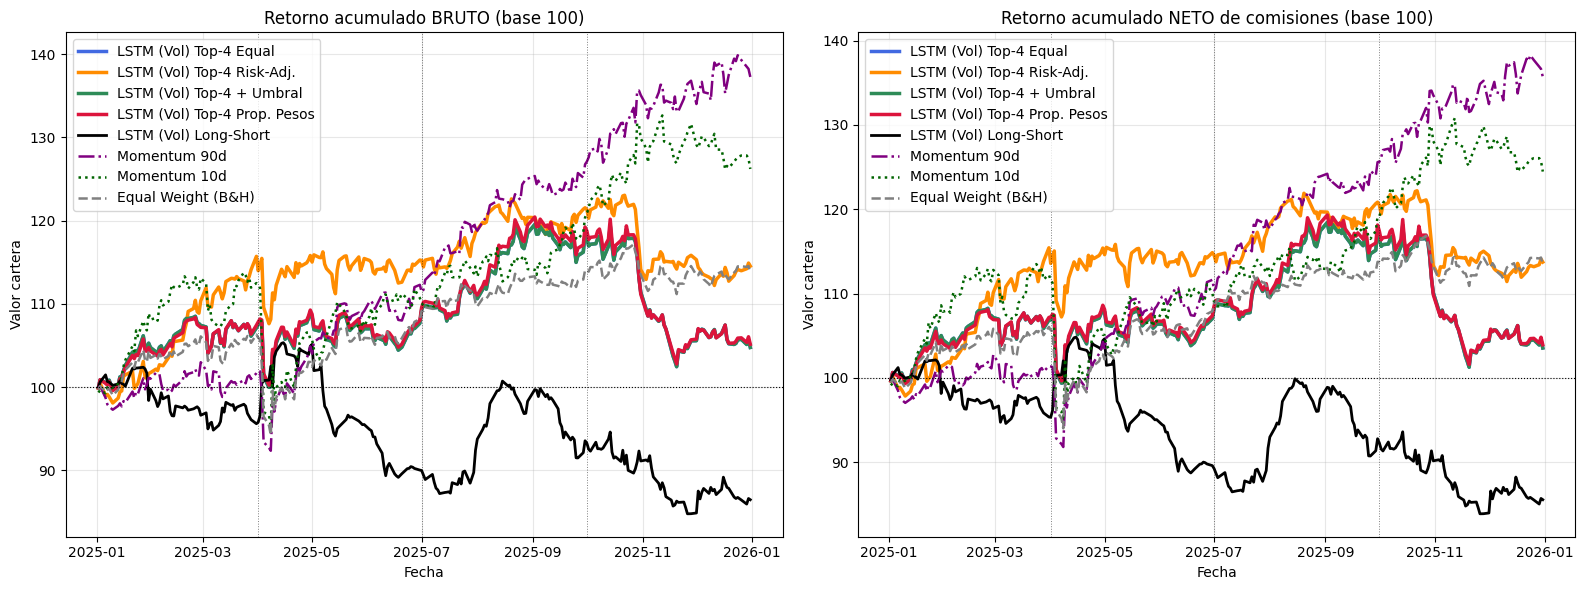

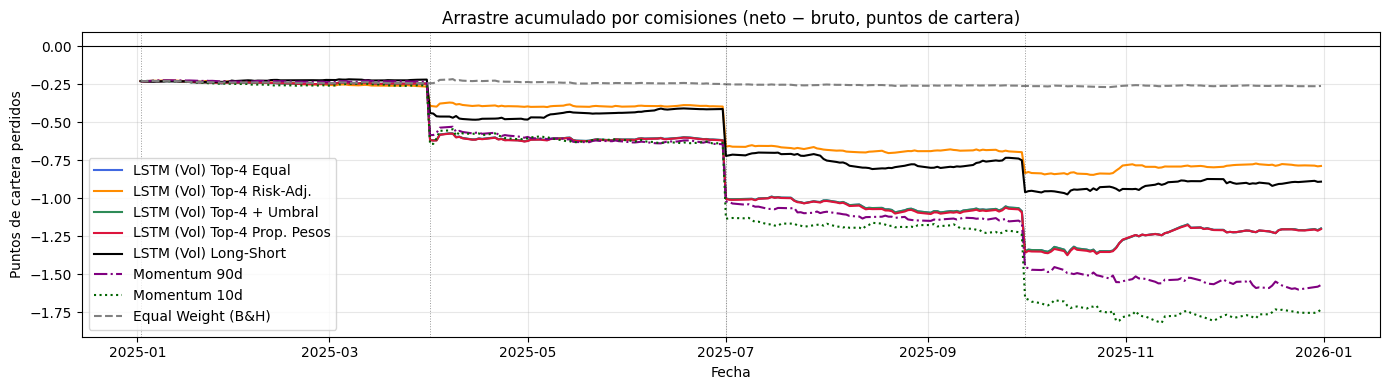


Ranking por retorno NETO (comisión = 0.23 %):
  Momentum 90d                  : +35.68 %   (bruto +37.25 %,  arrastre -1.572 p.)
  Momentum 10d                  : +24.47 %   (bruto +26.20 %,  arrastre -1.733 p.)
  LSTM (Vol) Risk-Adj.          : +13.74 %   (bruto +14.52 %,  arrastre -0.788 p.)
  Equal Weight                  : +13.47 %   (bruto +13.73 %,  arrastre -0.262 p.)
  LSTM (Vol) Prop. Pesos        :  +3.94 %   (bruto  +5.14 %,  arrastre -1.204 p.)
  LSTM (Vol) Equal              :  +3.56 %   (bruto  +4.76 %,  arrastre -1.200 p.)
  LSTM (Vol) Umbral             :  +3.56 %   (bruto  +4.76 %,  arrastre -1.200 p.)
  LSTM (Vol) Long-Short         : -14.42 %   (bruto -13.53 %,  arrastre -0.892 p.)


In [10]:
# ── Gráfico: retorno acumulado bruto vs neto ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

gross_cum = (ret_df.cumsum().apply(np.exp) * 100)

for ax, values_dict, title in zip(
    axes,
    [gross_cum, net_df],
    ["Retorno acumulado BRUTO (base 100)", "Retorno acumulado NETO de comisiones (base 100)"],
):
    for name, style in STYLE.items():
        ax.plot(values_dict.index, values_dict[name], **style)
    for rb in bt.rebalance_dates[1:]:
        ax.axvline(rb, color="black", lw=0.7, ls=":", alpha=0.5)
    ax.axhline(100, color="black", lw=0.8, ls=":")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Valor cartera")
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Gráfico: diferencia neto - bruto (arrastre por comisiones) ────────────────
fig, ax = plt.subplots(figsize=(14, 4))

for name, style in STYLE.items():
    drag = net_df[name] - gross_cum[name]
    ax.plot(drag.index, drag, color=style["color"], lw=1.5,
            ls=style["ls"], label=style["label"])

for rb in bt.rebalance_dates:
    ax.axvline(rb, color="black", lw=0.7, ls=":", alpha=0.4)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Arrastre acumulado por comisiones (neto − bruto, puntos de cartera)", fontsize=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Puntos de cartera perdidos")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Ranking neto final ────────────────────────────────────────────────────────
print(f"\nRanking por retorno NETO (comisión = {COMMISSION_RATE*100:.2f} %):")
ranking = net_df.iloc[-1].sort_values(ascending=False)
for name, val in ranking.items():
    label   = LABELS.get(name, name)
    bruto   = float(gross_cum[name].iloc[-1])
    drag    = float(val - bruto)
    print(f"  {label:30s}: {val - 100:+6.2f} %   (bruto {bruto - 100:+6.2f} %,  arrastre {drag:+.3f} p.)")